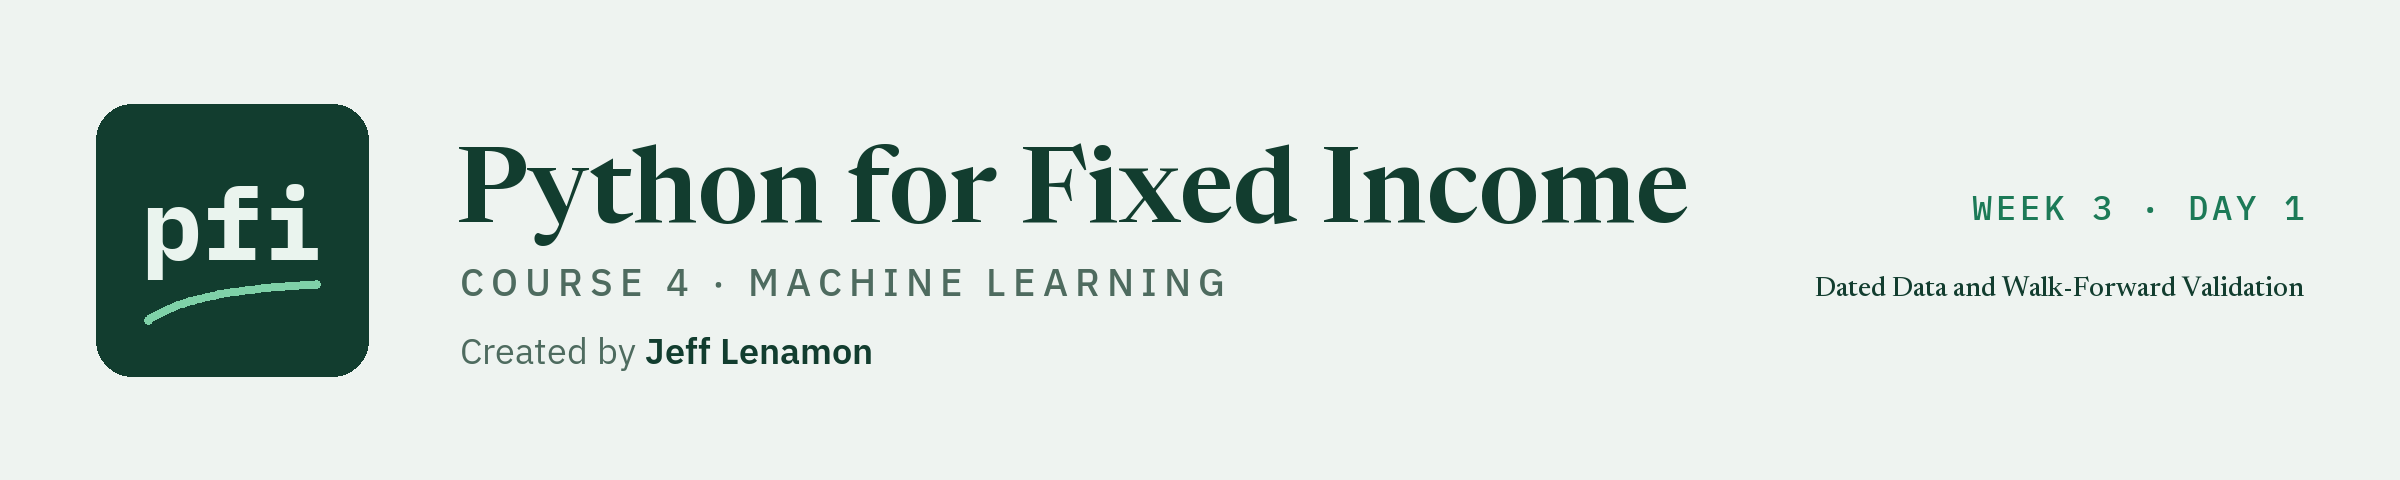

# Dated Data and Walk-Forward Validation

Week 3, Day 1. Dated rows break the random split: a neighbouring date is a near-copy, so a shuffled test set flatters every model. Today: the walk-forward split, scoring fold by fold, why the later folds are hard, ridge and lasso on collinear tenors, and lookahead in a feature.

**Data:** `treasury_par_yields.csv`, daily par yields 2015-01-02 to 2026-10-02: **real**, U.S. Treasury, public domain.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week3/day1/11_dated_data_and_walk_forward_validation.ipynb)

Weeks 1 and 2 fitted models to rows that had no order: bonds in week 1, card accounts in week 2, and last time the card file's case study, where the test rows were opened once at the end. Shuffling those rows before a split did no harm, because no row comes before another.

Week 3 opens with rows that do have an order. Each row of today's file is a **date**, and a date sits next to the day before and the day after, which look almost exactly like it. That one fact breaks the random split, and today you measure by how much.

| | |
| --- | --- |
| **Source** | U.S. Department of the Treasury, Daily Treasury Par Yield Curve Rates |
| **Page** | https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?type=daily_treasury_yield_curve |
| **Retrieved** | 2026-10-03, from the yearly CSV downloads on that page |
| **File** | `treasury_par_yields.csv` in the `data` folder of the course repo, 2,940 dates from 2015-01-02 to 2026-10-02 |
| **Reuse** | Treasury's public data inventory lists the dataset as public, under the CC0 1.0 public domain dedication (https://www.treasury.gov/jsonfiles/data.json) |

These are **par yields on Treasury securities**, in percent, to two decimals, as published. Treasury describes the series as a par yield curve based on closing market bid prices on the most recently auctioned Treasury securities (https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics). This is the first real market series a model in this course is fitted to.

**What the models describe, and what they do not.** Every model today has the same day's 30 Yr yield as its target and the same day's 2 Yr and 10 Yr yields as its features (section 11.7 uses the same day's changes). It describes the shape of the curve on a date that is already in the file. It is not a forecast: no model here looks at a later date, nothing is fitted for or reported at any date after 2026-10-02, and nothing in this notebook says what any result implies for rates or what anyone should do. Errors are out-of-sample errors inside the file's own span.

Today you will:

1. See why dated rows are different: a date's neighbours are near-copies of it.
2. Set the task, the 30 Yr given the same day's 2 Yr and 10 Yr, and the names its output may have.
3. Score a tree with a random split, and find out why it looks so good.
4. Write `walk_forward_splits` and `assert_past_only`, and score the same models in time order, beside scikit-learn's `TimeSeriesSplit`.
5. Find what makes the later folds hard: levels the training rows never reached.
6. Watch a relationship drift, with a rolling 252-row slope matched in Excel.
7. Use ridge and lasso where the features really are collinear: ten tenors' same-day changes.
8. Catch lookahead in a feature: a z-score over the whole history against a trailing window.

Q. Set up today's work folder: the thread settings, the seed, the course data, and the module as it stood at the end of day 10.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_11_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv", "credit_card_default.csv", "treasury_par_yields.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_11_9fyoz8u_, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv, credit_card_default.csv, treasury_par_yields.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))


from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def spread_pipeline(model) -> Pipeline:
    """Rating and sector one-hot (references A and Consumer), duration and coupon scaled, then `model`."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), ["duration", "coupon"]),
    ])
    return Pipeline([("encode", encode), ("model", model)])


def test_named_coefficients_align_with_names():
    bench = read_bench()
    X, y = bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"]
    pipeline = spread_pipeline(LinearRegression()).fit(X, y)
    coefficients = mlkit.named_coefficients(pipeline)
    assert list(coefficients.index) == list(pipeline[:-1].get_feature_names_out())
    assert np.array_equal(coefficients.to_numpy(), pipeline[-1].coef_)
    # the reference levels have no coefficient
    assert "categories__rating_A" not in coefficients.index
    assert "categories__sector_Consumer" not in coefficients.index
    assert "categories__rating_AAA" in coefficients.index


def test_named_coefficients_rejects_tree():
    bench = read_bench()
    pipeline = spread_pipeline(DecisionTreeRegressor(max_depth=2, random_state=SEED))
    pipeline.fit(bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"])
    with pytest.raises(ValueError, match="coef_"):
        mlkit.named_coefficients(pipeline)


def test_pipeline_scaler_fitted_on_train_only():
    bench = read_bench()
    X, y = bench[["duration", "coupon", "score"]], bench["log_oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train, y_train)
    # the scaler learned the training rows' means and population standard deviations, not all rows'
    assert np.allclose(pipeline["scale"].mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
    assert np.allclose(pipeline["scale"].scale_, X_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12)
    assert not np.allclose(pipeline["scale"].mean_, X.mean().to_numpy(), rtol=0, atol=1e-6)


from sklearn.linear_model import LogisticRegression

CARD_TARGET = "default payment next month"


def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, with LIMIT_BAL also in units of 10,000 NT dollars."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    card["LIMIT_BAL_10k"] = card["LIMIT_BAL"] / 10_000
    return card


def test_logistic_probability_hand_values():
    assert mlkit.logistic_probability(0.0) == pytest.approx(0.5, abs=1e-12)
    # log-odds of ln 3 are odds of 3 to 1, a probability of 0.75
    assert mlkit.logistic_probability(np.log(3)) == pytest.approx(0.75, abs=1e-12)
    probabilities = mlkit.logistic_probability(np.array([-np.log(3), 0.0]))
    assert probabilities == pytest.approx([0.25, 0.5], abs=1e-12)


def test_odds_ratios_exp():
    coefficients = pd.Series({"const": -1.4, "PAY_0": np.log(2.0), "LIMIT_BAL_10k": 0.0})
    ratios = mlkit.odds_ratios(coefficients)
    assert list(ratios.index) == ["PAY_0", "LIMIT_BAL_10k"]
    assert ratios["PAY_0"] == pytest.approx(2.0, abs=1e-12)
    assert ratios["LIMIT_BAL_10k"] == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.odds_ratios(pd.Series({"const": 1.0}))


@pytest.mark.parametrize("model, features", [
    ("d06_logit_default_on_pay0", ["PAY_0"]),
    ("d06_logit_default_on_pay0_limit10k", ["PAY_0", "LIMIT_BAL_10k"]),
])
def test_logit_matches_excel_solver_reference(model, features):
    card = read_card()
    logit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features]))
    fit = logit.fit(disp=0)
    # Excel Solver, non-negative box off, maximising the summed log-likelihood column
    solver = pd.Series({name: excel(f"{model}:coef_{name}") for name in ["const"] + features})
    for name in solver.index:
        assert fit.params[name] == pytest.approx(solver[name], abs=1e-4), name
    # the log-likelihood Excel summed, at Excel's own coefficients
    assert logit.loglike(solver[fit.params.index].to_numpy()) == pytest.approx(excel(f"{model}:loglik"), abs=1e-6)
    # Excel: =EXP(coef) as an odds ratio
    for name, ratio in mlkit.odds_ratios(solver).items():
        assert ratio == pytest.approx(excel(f"{model}:odds_ratio_{name}"), abs=1e-12)


@pytest.mark.parametrize("features", [["PAY_0"], ["PAY_0", "LIMIT_BAL_10k"]])
def test_sklearn_cinf_matches_statsmodels(features):
    card = read_card()
    fit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features])).fit(disp=0)
    # C=np.inf switches the default L2 penalty off; penalty= is never used (deprecated in scikit-learn 1.8).
    # tol=1e-8: with the default tol=1e-4 the solver stops 2.2e-4 away on PAY_0 alone
    model = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(card[features], card[CARD_TARGET])
    assert model.intercept_[0] == pytest.approx(fit.params["const"], abs=1e-4)
    for name, value in zip(features, model.coef_[0]):
        assert value == pytest.approx(fit.params[name], abs=1e-4), name


from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score


def pay0_flags(threshold: float = 0.5) -> tuple[pd.Series, np.ndarray]:
    """Actual defaults and flags of the logistic model on PAY_0, at Excel Solver's coefficients."""
    card = read_card()
    model = "d06_logit_default_on_pay0"
    z = excel(f"{model}:coef_const") + excel(f"{model}:coef_PAY_0") * card["PAY_0"]
    return card[CARD_TARGET], (mlkit.logistic_probability(z) >= threshold).astype(int)


def test_confusion_counts_hand():
    counts = mlkit.confusion_counts([0, 0, 1, 1, 1, 0], [0, 1, 1, 0, 1, 0])
    assert counts == {"tn": 2, "fp": 1, "fn": 1, "tp": 2}


def test_confusion_counts_match_sklearn():
    y, flags = pay0_flags()
    counts = mlkit.confusion_counts(y, flags)
    tn, fp, fn, tp = confusion_matrix(y, flags).ravel()
    assert counts == {"tn": tn, "fp": fp, "fn": fn, "tp": tp}
    # Excel: =COUNTIFS(actual, 1, probability, ">=0.5") and the other three
    for name, value in counts.items():
        assert value == excel(f"d07_confusion_pay0_at_0.5:{name}")


def test_metrics_match_sklearn():
    y, flags = pay0_flags()
    metrics = mlkit.classification_metrics(y, flags)
    assert metrics["accuracy"] == pytest.approx(accuracy_score(y, flags), abs=1e-12)
    assert metrics["precision"] == pytest.approx(precision_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["recall"] == pytest.approx(recall_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["f1"] == pytest.approx(f1_score(y, flags, zero_division=0), abs=1e-12)
    for name in ("accuracy", "precision", "recall", "f1"):
        assert metrics[name] == pytest.approx(excel(f"d07_confusion_pay0_at_0.5:{name}"), abs=1e-12)


def test_metrics_zero_division():
    # a model that flags nothing: precision, recall, and F1 are 0 by convention, not an error
    metrics = mlkit.classification_metrics([0, 1, 1, 0], [0, 0, 0, 0])
    assert metrics == {"accuracy": 0.5, "precision": 0.0, "recall": 0.0, "f1": 0.0}


def test_rejects_labels_other_than_0_1():
    with pytest.raises(ValueError, match="other than 0 and 1"):
        mlkit.confusion_counts([0, 1, 2], [0, 1, 1])
    with pytest.raises(ValueError):
        mlkit.classification_metrics([0, 1], [True, 0.5])


from sklearn.metrics import roc_curve


def card_split() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """The card file's 60/20/20 split, stratified, seed 42: 18,000 training, 6,000 validation, 6,000 test rows.
    The four person columns (SEX, EDUCATION, MARRIAGE, AGE) and ID are never features."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    features = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
        [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
    X, y = card[features], card[CARD_TARGET]
    X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=SEED)
    return X_train, X_valid, X_test, y_train, y_valid, y_test


def validation_proba() -> tuple[pd.Series, np.ndarray]:
    """Validation outcomes and probabilities of a scaled logistic regression fitted on the training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    return y_valid, model.predict_proba(X_valid)[:, 1]


def test_threshold_for_recall_hand():
    y = [1, 0, 1, 0, 1, 0]
    proba = [0.9, 0.8, 0.7, 0.4, 0.3, 0.1]
    # at 0.7 two of three defaults are caught (recall 2/3); at 0.3 all three
    assert mlkit.threshold_for_recall(y, proba, 0.6) == 0.7
    assert mlkit.threshold_for_recall(y, proba, 0.7) == 0.3
    assert mlkit.threshold_for_recall(y, proba, 1.0) == 0.3
    # tied probabilities are flagged together
    assert mlkit.threshold_for_recall([1, 1, 0, 1], [0.6, 0.5, 0.5, 0.2], 0.5) == 0.5


def test_threshold_meets_target():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    recall = mlkit.classification_metrics(y_valid, (proba >= threshold).astype(int))["recall"]
    assert recall >= 0.70
    # roc_curve flags rows with score >= threshold too: the true positive rate there is the same recall
    # (drop_intermediate=False keeps every distinct probability as a threshold)
    fpr, tpr, thresholds = roc_curve(y_valid, proba, drop_intermediate=False)
    assert tpr[thresholds == threshold][0] == pytest.approx(recall, abs=1e-12)


def test_threshold_is_highest():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    higher = np.unique(proba[proba > threshold])
    # the next distinct probability above the threshold misses the target
    next_up = higher.min()
    assert mlkit.classification_metrics(y_valid, (proba >= next_up).astype(int))["recall"] < 0.70


def test_threshold_rejects_bad_target():
    for target in (0.0, -0.1, 1.2):
        with pytest.raises(ValueError):
            mlkit.threshold_for_recall([0, 1], [0.2, 0.8], target)
    with pytest.raises(ValueError, match="no row of class 1"):
        mlkit.threshold_for_recall([0, 0], [0.2, 0.8], 0.5)


from sklearn.model_selection import KFold, StratifiedKFold


def test_cv_folds_classification_is_stratified():
    folds = mlkit.cv_folds()
    assert isinstance(folds, StratifiedKFold)
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)
    X_train, _, _, y_train, _, _ = card_split()
    overall = y_train.mean()
    for train_positions, test_positions in folds.split(X_train, y_train):
        mlkit.assert_disjoint(train_positions, test_positions)
        # each fold keeps the training rows' default rate to within one account
        assert abs(y_train.iloc[test_positions].mean() - overall) < 1 / len(test_positions) + 1e-12


def test_cv_folds_regression():
    folds = mlkit.cv_folds("regression")
    assert type(folds) is KFold
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)


def test_cv_folds_rejects_unknown():
    with pytest.raises(ValueError, match="time"):
        mlkit.cv_folds("time")


from sklearn.exceptions import NotFittedError
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier


def fitted_models() -> tuple[dict, pd.DataFrame, pd.Series]:
    """A scaled logistic regression and a depth-3 balanced tree fitted on the card training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    models = {
        "logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
        "tree": DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=SEED),
    }
    for model in models.values():
        model.fit(X_train, y_train)
    return models, X_valid, y_valid


def test_compare_models_columns():
    models, X_valid, y_valid = fitted_models()
    table = mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2, "tree": 0.5})
    assert list(table.index) == ["logistic", "tree"]
    assert list(table.columns) == ["roc_auc", "average_precision", "threshold", "accuracy", "precision", "recall",
                                   "f1"]
    proba = models["logistic"].predict_proba(X_valid)[:, 1]
    assert table.loc["logistic", "roc_auc"] == pytest.approx(roc_auc_score(y_valid, proba), abs=1e-12)
    assert table.loc["logistic", "average_precision"] == pytest.approx(average_precision_score(y_valid, proba),
                                                                         abs=1e-12)
    flags = (proba >= 0.2).astype(int)
    assert table.loc["logistic", "recall"] == pytest.approx(recall_score(y_valid, flags), abs=1e-12)
    with pytest.raises(ValueError, match="tree"):
        mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2})


def test_compare_models_does_not_refit():
    models, X_valid, y_valid = fitted_models()
    before = models["logistic"]["model"].coef_.copy()
    mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2, "tree": 0.5})
    # the coefficients learned on the training rows are untouched
    assert np.array_equal(models["logistic"]["model"].coef_, before)
    # and a model nobody fitted is refused, not fitted on the rows given
    with pytest.raises(NotFittedError):
        mlkit.compare_models({"new": LogisticRegression()}, X_valid, y_valid, {"new": 0.5})


def test_assert_descriptive_passes_plain_text():
    mlkit.assert_descriptive("In this file the model ranked 72 percent of default and non-default pairs correctly. "
                             "A willing reader can check every number.")


def test_assert_descriptive_names_the_word():
    with pytest.raises(ValueError, match=r"\['will', 'cheap'\]"):
        mlkit.assert_descriptive("These bonds look Cheap and spreads WILL tighten.")

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests', 'named_coefficients', 'odds_ratios', 'logistic_probability', 'confusion_counts', 'classification_metrics', 'threshold_for_recall', 'cv_folds', 'compare_models', 'assert_descriptive']


* The setup copies every data file the module's tests read, the Treasury file among them, and writes `mlkit.py` and `test_mlkit.py` as they stood at the end of day 10. Today's notebook reads only the Treasury file.

## 11.1 Why Dated Rows Are Different

Q. Load the Treasury file and keep the tenors that have a value on every date.

In [5]:
# one row per date published, yields in percent; the dates become the index
treasury = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"]).set_index("date")
# the checks every dated file gets: no date twice, and in order
assert treasury.index.is_unique and treasury.index.is_monotonic_increasing

# three tenors begin partway through the file; keep the eleven with a value on every date
full_tenors = [column for column in treasury.columns if treasury[column].notna().all()]
curve = treasury[full_tenors]
print(f"{len(curve):,} dates from {curve.index[0].date()} to {curve.index[-1].date()}")
print(f"{len(full_tenors)} tenors with a value on every date: {full_tenors}")

2,940 dates from 2015-01-02 to 2026-10-02
11 tenors with a value on every date: ['1 Mo', '3 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr', '10 Yr', '20 Yr', '30 Yr']


* 2,940 dates and eleven full tenors. The `1.5 Month`, `2 Mo`, and `4 Mo` columns start partway through the file (DATA.md lists their first dates) and are left out today.

Q. How close is each date's 30 Yr yield to the day before?

In [6]:
thirty = curve["30 Yr"]
# the size of each day's move in bp, and the whole range the 30 Yr covers in the file
moves_bp = thirty.diff().abs() * 100
print(f"30 Yr range in the file: {thirty.min():.2f} to {thirty.max():.2f} percent, "
      f"{(thirty.max() - thirty.min()) * 100:.0f} bp from lowest to highest")
print(f"median move from one date to the next: {moves_bp.median():.1f} bp")

# correlation of each date's value with the date before (lag 1), for the level and for the daily change
print(f"30 Yr level against the date before: correlation {thirty.autocorr(1):.4f}")
print(f"30 Yr daily change against the change the date before: correlation {(thirty.diff() * 100).autocorr(1):.4f}")

30 Yr range in the file: 0.99 to 5.64 percent, 465 bp from lowest to highest
median move from one date to the next: 3.0 bp
30 Yr level against the date before: correlation 0.9989
30 Yr daily change against the change the date before: correlation -0.0207


* The 30 Yr covers 465 bp over the file, from 0.99 percent on 2020-03-09 to 5.64 percent on 2026-09-30, but the median move from one date to the next is 3.0 bp. A date's level is almost a copy of the date before: the correlation is 0.9989.
* The daily **changes** do not repeat that way: one day's change and the next have a correlation of -0.0207. Levels sit next to near-copies; changes do not. Keep that in mind for section 11.7.
* This is the "rows that are not independent" line of day 1's table of failures. For bonds it meant an issuer's bonds on both sides of a split. For dates it means a test date with its own near-copy, the day before, in the training rows.

## 11.2 The Task, and Why It Is Not a Forecast

Today's model answers one question about the curve's shape: **given the 2 Yr and the 10 Yr yield on a date, what 30 Yr yield goes with them on that same date?** All three are read off the same row. The model never sees a later date, so it says nothing about what comes next; it describes how the long end sat relative to the 2 Yr and the 10 Yr, date by date, in this file.

| Allowed name | What it means |
| --- | --- |
| fitted 30 Yr yield given the same day's 2 Yr and 10 Yr | The model's output for a date in the file |
| out-of-sample error inside the file's span | Actual minus fitted, in bp, on test dates the model was not fitted on, all before the file's last date |

A fitted 30 Yr yield is never called a forecast, an expectation, a fair value, or a view on rates, and a gap between the actual and the fitted yield is never a signal. It describes how far one curve shape learned from some dates misses on other dates.

Q. Set the features and the target, and draw the three yields over the file.

X: 2,940 dates by 2 columns; y: 2,940 yields in percent


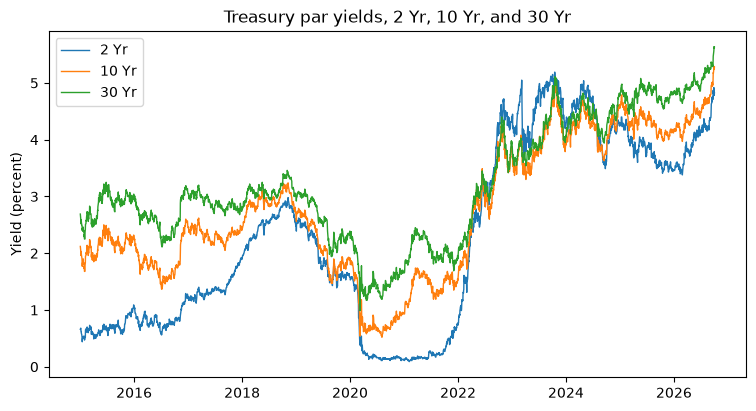

In [7]:
import matplotlib.pyplot as plt

# the features: the same day's 2 Yr and 10 Yr yields, in percent; the target: that day's 30 Yr yield, in percent
X = curve[["2 Yr", "10 Yr"]]
y = curve["30 Yr"]
print(f"X: {X.shape[0]:,} dates by {X.shape[1]} columns; y: {len(y):,} yields in percent")

fig, ax = plt.subplots(figsize=(9, 4.5))
for column in ["2 Yr", "10 Yr", "30 Yr"]:
    ax.plot(curve.index, curve[column], linewidth=1, label=column)
ax.set_title("Treasury par yields, 2 Yr, 10 Yr, and 30 Yr")
ax.set_ylabel("Yield (percent)")
ax.legend()
plt.show()

* The three lines move together, and they also change places: in some years the 2 Yr sits far below the 10 Yr, in others above it. The 30 Yr's distance from the other two is not fixed, and that is what makes the task worth fitting.
* The chart describes the file. It says nothing about any date after the last one.

## 11.3 A Random Split: a Tree Looks Excellent

Week 2's decision tree had a regression cousin: `DecisionTreeRegressor` asks the same kind of yes-or-no questions about the features, and each leaf holds the **mean target of the training rows that land in it**. Left at its defaults it grows until its leaves are nearly pure, as day 9's default tree did.

To score a model on several splits, each split is a **fold**: fit on its training rows, then measure the error on its test rows. The helper below does that for any model and any list of folds. It refits a fresh copy in every fold (`clone`), so no fold starts from another fold's fit.

Q. Write the fold-by-fold helper.

In [8]:
from sklearn.base import clone


def score_folds(model, X, y, splits, bp_per_unit):
    """Fit a fresh copy of model on each fold's training rows and measure it on that fold's test rows.

    splits: a list of (train_positions, test_positions). bp_per_unit: 100 when y is a yield in percent,
    1 when y is already in bp. Returns one row per fold (test dates, rows, MAE and RMSE in bp, R-squared),
    the fitted value of every test row (in y's unit, indexed by date), and the fitted models.
    """
    rows, fitted_parts, models = [], [], []
    for number, (train, test) in enumerate(splits, start=1):
        # clone makes an unfitted copy, so every fold starts from scratch
        fitted_model = clone(model).fit(X.iloc[train], y.iloc[train])
        fitted = pd.Series(fitted_model.predict(X.iloc[test]), index=X.index[test])
        metrics = mlkit.regression_metrics(y.iloc[test], fitted)
        rows.append({"fold": number, "test_first": X.index[test].min().date(), "test_last": X.index[test].max().date(),
                     "train_rows": len(train), "test_rows": len(test), "mae_bp": metrics["mae"] * bp_per_unit,
                     "rmse_bp": metrics["rmse"] * bp_per_unit, "r2": metrics["r2"]})
        fitted_parts.append(fitted)
        models.append(fitted_model)
    return pd.DataFrame(rows).set_index("fold"), pd.concat(fitted_parts).sort_index(), models


def pooled(fitted, y, bp_per_unit):
    """R-squared, MAE, and RMSE over every test row of every fold together; MAE and RMSE in bp."""
    metrics = mlkit.regression_metrics(y.loc[fitted.index], fitted)
    return {"r2": metrics["r2"], "mae_bp": metrics["mae"] * bp_per_unit, "rmse_bp": metrics["rmse"] * bp_per_unit}

* `pooled` measures every test row of every fold at once. When the folds are the same size, its MAE equals the mean of the folds' MAEs.

Q. Score the default tree with five shuffled folds, the way weeks 1 and 2 would have.

In [9]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor

# five folds of dates drawn at random: the shuffle ignores the order of the dates
random_splits = list(KFold(n_splits=5, shuffle=True, random_state=SEED).split(X))
tree = DecisionTreeRegressor(random_state=SEED)

random_tree_folds, random_tree_fitted, _ = score_folds(tree, X, y, random_splits, bp_per_unit=100)
print(random_tree_folds[["test_first", "test_last", "test_rows", "mae_bp", "r2"]].round({"mae_bp": 1, "r2": 4}).to_string())
random_tree = pooled(random_tree_fitted, y, bp_per_unit=100)
print(f"every test row: MAE {random_tree['mae_bp']:.1f} bp, R-squared {random_tree['r2']:.4f}")

      test_first   test_last  test_rows  mae_bp      r2
fold                                                   
1     2015-01-21  2026-10-02        588     3.9  0.9962
2     2015-01-02  2026-10-01        588     4.6  0.9943
3     2015-01-06  2026-09-30        588     4.6  0.9950
4     2015-01-07  2026-09-08        588     4.6  0.9938
5     2015-01-05  2026-09-23        588     4.5  0.9951
every test row: MAE 4.5 bp, R-squared 0.9949


* The fitted 30 Yr yield given the same day's 2 Yr and 10 Yr misses by 4.5 bp on average, with an R-squared of 0.9949. Every fold's test dates run from the first year of the file to the last.
* That is a remarkably small error for a model that knows two numbers per date. The next cell shows where it comes from.

Q. For each test date of the first fold, how far away is the nearest training date?

In [10]:
train_0, test_0 = random_splits[0]
training_positions = np.sort(train_0)
# for each test row, the distance in rows to the closest training row
distance = np.array([np.min(np.abs(training_positions - position)) for position in test_0])
print(f"{len(test_0)} test dates; nearest training date one row away: {(distance == 1).mean():.1%}; "
      f"farthest: {distance.max()} rows")

588 test dates; nearest training date one row away: 97.1%; farthest: 2 rows


* 97.1 percent of the 588 test dates have a training date right next to them, and none is more than 2 rows from one. With a median move of 3.0 bp a day, the tree only has to find the neighbour and read off its 30 Yr yield.
* So the random split does not measure how one curve shape carries over to other dates. It measures how well the model remembers yesterday. Section 11.4 removes the neighbours.

Q. And the straight line, on the same random folds?

In [11]:
from sklearn.linear_model import LinearRegression

linear = LinearRegression()
random_linear_folds, random_linear_fitted, _ = score_folds(linear, X, y, random_splits, bp_per_unit=100)
random_linear = pooled(random_linear_fitted, y, bp_per_unit=100)
print(f"linear model, random folds: MAE {random_linear['mae_bp']:.1f} bp, R-squared {random_linear['r2']:.4f}")

linear model, random folds: MAE 10.8 bp, R-squared 0.9840


* 10.8 bp: the line cannot copy a neighbour, because one plane through all the dates has to serve every date. On a random split the tree looks more than twice as good as the line.

## 11.4 Walk-Forward: Train on the Past, Test on What Follows

The fix is to split by time. In a **walk-forward** (expanding-window) split, the first fold trains on the first stretch of dates and tests on the stretch right after it. The next fold adds that stretch to the training rows and tests on the following one, and so on to the end of the file:

```
fold 1:  [ train ............ ][ test ]
fold 2:  [ train ...................... ][ test ]
fold 3:  [ train ................................ ][ test ]
```

Every training date is before every test date, nothing is shuffled, and each date is tested once. The course's settings: the first **504** rows to train (about two years of market dates), test windows of **126** rows (about six months), and a gap of **0** rows, because today's target is the same day's yield (a target that spans h days needs a gap of h rows, exercise 2). A last window shorter than 126 rows is dropped.

Q. Add `walk_forward_splits` to `mlkit.py`. Read the docstring first: the inputs, the output, the convention, and what stops it.

In [12]:
%%writefile -a mlkit.py


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits

Appending to mlkit.py


* The function returns **positions**, not dates: `X.iloc[train]` then picks the rows. It checks the dates first, because a split in time order means nothing on dates out of order.

Q. Add its first test, on ten hand-made business days, and run the tests.

In [13]:
%%writefile -a test_mlkit.py


from sklearn.model_selection import TimeSeriesSplit


def treasury_dates() -> pd.DatetimeIndex:
    """The 2,940 dates of the Treasury par yield file, 2015-01-02 to 2026-10-02."""
    return pd.DatetimeIndex(pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"])["date"])


def test_walk_forward_hand_index():
    dates = pd.date_range("2026-01-05", periods=10, freq="B")
    splits = mlkit.walk_forward_splits(dates, min_train=4, test_size=2)
    expected = [([0, 1, 2, 3], [4, 5]), ([0, 1, 2, 3, 4, 5], [6, 7]), ([0, 1, 2, 3, 4, 5, 6, 7], [8, 9])]
    assert [(train.tolist(), test.tolist()) for train, test in splits] == expected
    # a last window of one row is dropped
    assert len(mlkit.walk_forward_splits(dates[:9], min_train=4, test_size=2)) == 2

Appending to test_mlkit.py


In [14]:
# the file changed, so reload before using the new function
importlib.reload(mlkit)
print(f"walk_forward_splits in mlkit: {hasattr(mlkit, 'walk_forward_splits')}")

walk_forward_splits in mlkit: True


In [15]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...........................................                              [100%]
43 passed in 3.58s



* `43 passed`: the module's 42 tests from weeks 1 and 2 and today's first. The hand test checks the exact positions of three folds and that a last window of one row is dropped.

Q. Make the walk-forward folds of the Treasury file.

In [16]:
# about two years to start, then six-month test windows, no gap for a same-day target
wf_splits = mlkit.walk_forward_splits(curve.index, min_train=504, test_size=126)

folds = pd.DataFrame([{"train_first": curve.index[train[0]].date(), "train_last": curve.index[train[-1]].date(),
                       "train_rows": len(train), "test_first": curve.index[test[0]].date(),
                       "test_last": curve.index[test[-1]].date(), "test_rows": len(test)}
                      for train, test in wf_splits], index=pd.RangeIndex(1, len(wf_splits) + 1, name="fold"))
print(f"{len(wf_splits)} folds; the last {len(curve) - 1 - wf_splits[-1][1][-1]} dates are left over (shorter than one window)")
pd.concat([folds.head(3), folds.tail(2)])

19 folds; the last 42 dates are left over (shorter than one window)


,train_first,train_last,train_rows,test_first,test_last,test_rows
fold,,,,,,
1,2015-01-02,2017-01-05,504,2017-01-06,2017-07-07,126
2,2015-01-02,2017-07-07,630,2017-07-10,2018-01-08,126
3,2015-01-02,2018-01-08,756,2018-01-09,2018-07-10,126
18,2015-01-02,2025-07-31,2646,2025-08-01,2026-02-03,126
19,2015-01-02,2026-02-03,2772,2026-02-04,2026-08-04,126


* 19 folds. The first trains on 2015-01-02 to 2017-01-05 and tests the next 126 dates; the last tests up to 2026-08-04. The final 42 dates of the file do not fill a window and are not tested.
* Each fold's training rows hold every date before its test window, so the training set grows by 126 rows a fold.

Q. Add `assert_past_only`, the check every dated split gets, and the other four tests.

In [17]:
%%writefile -a mlkit.py


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")

Appending to mlkit.py


* `assert_past_only` compares the latest training date with the earliest test date. With `gap` and the full calendar, it also counts the dates between them.
* `assert_disjoint` (day 1) checks that no row is on both sides; `assert_past_only` checks the order. A dated split needs both.

In [18]:
%%writefile -a test_mlkit.py


def test_walk_forward_gap():
    dates = pd.date_range("2026-01-05", periods=10, freq="B")
    splits = mlkit.walk_forward_splits(dates, min_train=4, test_size=2, gap=1)
    assert [(train.tolist(), test.tolist()) for train, test in splits] == [
        ([0, 1, 2, 3], [5, 6]), ([0, 1, 2, 3, 4, 5], [7, 8])]
    for train, test in splits:
        mlkit.assert_past_only(dates[train], dates[test], gap=1, calendar=dates)
    # scikit-learn's TimeSeriesSplit with the same test size and gap gives the same positions
    ours = mlkit.walk_forward_splits(dates, min_train=5, test_size=2, gap=1)
    library = TimeSeriesSplit(n_splits=2, test_size=2, gap=1).split(np.zeros(len(dates)))
    assert [(a.tolist(), b.tolist()) for a, b in ours] == [(a.tolist(), b.tolist()) for a, b in library]


def test_walk_forward_past_only():
    dates = treasury_dates()
    # about two years to start, about six months per test window
    splits = mlkit.walk_forward_splits(dates, min_train=504, test_size=126)
    assert len(splits) == (len(dates) - 504) // 126
    for train, test in splits:
        mlkit.assert_disjoint(train, test)
        mlkit.assert_past_only(dates[train], dates[test])
        assert len(test) == 126


def test_walk_forward_rejects_unsorted():
    dates = pd.DatetimeIndex(["2026-01-06", "2026-01-05", "2026-01-07", "2026-01-08"])
    with pytest.raises(ValueError, match="ascending"):
        mlkit.walk_forward_splits(dates, min_train=2, test_size=1)
    with pytest.raises(ValueError, match="unique"):
        mlkit.walk_forward_splits(pd.DatetimeIndex(["2026-01-05"] * 4), min_train=2, test_size=1)


def test_assert_past_only_raises():
    dates = treasury_dates()
    # a shuffled split puts later dates in training: it is refused
    shuffled = KFold(5, shuffle=True, random_state=SEED)
    train, test = next(shuffled.split(np.zeros(len(dates))))
    with pytest.raises(AssertionError, match="not before"):
        mlkit.assert_past_only(dates[train], dates[test])
    # a gap of 5 rows asked for, 0 given
    with pytest.raises(AssertionError, match="gap of 5"):
        mlkit.assert_past_only(dates[:100], dates[100:110], gap=5, calendar=dates)
    with pytest.raises(ValueError, match="calendar"):
        mlkit.assert_past_only(dates[:100], dates[105:110], gap=5)

Appending to test_mlkit.py


* The tests check the gap by hand and against `TimeSeriesSplit`, every Treasury fold with both checks, dates out of order and repeated, and a shuffled split refused.

Q. Reload and run all the tests.

In [19]:
importlib.reload(mlkit)
print(f"assert_past_only in mlkit: {hasattr(mlkit, 'assert_past_only')}")

assert_past_only in mlkit: True


In [20]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...............................................                          [100%]
47 passed in 3.17s



* `47 passed`.

Q. Do the walk-forward folds pass both checks?

In [21]:
for train, test in wf_splits:
    # no row on both sides, and every training date before every test date
    mlkit.assert_disjoint(train, test)
    mlkit.assert_past_only(curve.index[train], curve.index[test])
print(f"all {len(wf_splits)} walk-forward folds use only the past")

all 19 walk-forward folds use only the past


Q. And the first random fold of section 11.3?

In [22]:
try:
    mlkit.assert_past_only(curve.index[train_0], curve.index[test_0])
except AssertionError as error:
    print(f"AssertionError: {error}")

AssertionError: a training date (2026-10-01) is not before the first test date (2015-01-21)


* Refused: `a training date (2026-10-01) is not before the first test date (2015-01-21)`. The random fold trains on dates up to the last day of the file and tests dates from the first year.

Q. Score the tree and the straight line on the walk-forward folds.

In [23]:
wf_tree_folds, wf_tree_fitted, wf_tree_models = score_folds(tree, X, y, wf_splits, bp_per_unit=100)
wf_linear_folds, wf_linear_fitted, wf_linear_models = score_folds(linear, X, y, wf_splits, bp_per_unit=100)
wf_tree, wf_linear = pooled(wf_tree_fitted, y, bp_per_unit=100), pooled(wf_linear_fitted, y, bp_per_unit=100)

by_fold = pd.DataFrame({"test_first": wf_tree_folds["test_first"], "test_last": wf_tree_folds["test_last"],
                        "tree MAE (bp)": wf_tree_folds["mae_bp"], "linear MAE (bp)": wf_linear_folds["mae_bp"]})
print(by_fold.round(1).to_string())

      test_first   test_last  tree MAE (bp)  linear MAE (bp)
fold                                                        
1     2017-01-06  2017-07-07            5.4             11.9
2     2017-07-10  2018-01-08            9.3             12.1
3     2018-01-09  2018-07-10           13.6             13.7
4     2018-07-11  2019-01-11            7.2              7.7
5     2019-01-14  2019-07-15            7.4              9.9
6     2019-07-16  2020-01-15           18.4              9.4
7     2020-01-16  2020-07-16           58.3             20.0
8     2020-07-17  2021-01-19            5.3              6.4
9     2021-01-20  2021-07-19           12.1             13.6
10    2021-07-20  2022-01-19           19.6             24.3
11    2022-01-20  2022-07-21           14.4             13.2
12    2022-07-22  2023-01-24           28.2             17.1
13    2023-01-25  2023-07-25            9.8             20.5
14    2023-07-26  2024-01-25           20.7             16.9
15    2024-01-26  2024-0

* These are out-of-sample errors inside the file's span: each fold's fitted 30 Yr yields come from a model fitted only on earlier dates. Fold errors run from 3.8 to 58.3 bp for the tree and from 6.4 to 28.6 bp for the line. The tree has the smaller error in 12 of the 19 folds.

Q. Put the random split and the walk-forward split side by side.

In [24]:
comparison = pd.DataFrame({
    "tree MAE (bp)": [random_tree["mae_bp"], wf_tree["mae_bp"]],
    "linear MAE (bp)": [random_linear["mae_bp"], wf_linear["mae_bp"]],
    "tree R-squared": [random_tree["r2"], wf_tree["r2"]],
    "linear R-squared": [random_linear["r2"], wf_linear["r2"]],
}, index=["random, 5 shuffled folds", f"walk-forward, {len(wf_splits)} folds"])
comparison.round({"tree MAE (bp)": 1, "linear MAE (bp)": 1, "tree R-squared": 4, "linear R-squared": 4})

,tree MAE (bp),linear MAE (bp),tree R-squared,linear R-squared
"random, 5 shuffled folds",4.5,10.8,0.9949,0.9840
"walk-forward, 19 folds",15.3,14.9,0.9557,0.9767


* The tree's error grows from 4.5 bp to 15.3 bp, about 3.4 times, once it can no longer read a neighbour. The line's grows too, from 10.8 to 14.9 bp, and the gap between the two models closes. The random split ranked the tree far ahead; in time order the two are close.
* These are not forecast errors. Both are out-of-sample errors inside the file's span: how far a curve shape learned on earlier dates misses on later dates that are already in the file.

Q. scikit-learn has a walk-forward splitter, `TimeSeriesSplit`. What folds does it make with its default settings?

In [25]:
from sklearn.model_selection import TimeSeriesSplit

# five folds; no shuffle by design, so no random_state
tss_splits = list(TimeSeriesSplit(n_splits=5).split(X))
pd.DataFrame([{"train_first": curve.index[train[0]].date(), "train_last": curve.index[train[-1]].date(),
               "train_rows": len(train), "test_first": curve.index[test[0]].date(),
               "test_last": curve.index[test[-1]].date(), "test_rows": len(test)}
              for train, test in tss_splits], index=pd.RangeIndex(1, 6, name="fold"))

,train_first,train_last,train_rows,test_first,test_last,test_rows
fold,,,,,,
1,2015-01-02,2016-12-14,490,2016-12-15,2018-11-29,490
2,2015-01-02,2018-11-29,980,2018-11-30,2020-11-16,490
3,2015-01-02,2020-11-16,1470,2020-11-17,2022-10-31,490
4,2015-01-02,2022-10-31,1960,2022-11-01,2024-10-16,490
5,2015-01-02,2024-10-16,2450,2024-10-17,2026-10-02,490


* Five folds of 490 test rows each, about two years. The first trains on 2015-01-02 to 2016-12-14 and tests 2016-12-15 to 2018-11-29; the fifth tests 2024-10-17 to 2026-10-02. `TimeSeriesSplit` lays its windows back from the **end** of the file, so the last test row is the file's last date.

Q. With 126-row windows, does `TimeSeriesSplit` make the same folds as `walk_forward_splits`?

In [26]:
library_splits = list(TimeSeriesSplit(n_splits=len(wf_splits), test_size=126).split(X))
print(f"TimeSeriesSplit: first training window {len(library_splits[0][0])} rows; last test date {curve.index[library_splits[-1][1][-1]].date()}")
print(f"walk_forward_splits: first training window {len(wf_splits[0][0])} rows; last test date {curve.index[wf_splits[-1][1][-1]].date()}")
same_test_rows = all(np.array_equal(ours, library) for (_, ours), (_, library) in zip(wf_splits, library_splits))
print(f"the same test rows: {same_test_rows}")

TimeSeriesSplit: first training window 546 rows; last test date 2026-10-02
walk_forward_splits: first training window 504 rows; last test date 2026-08-04
the same test rows: False


* Not quite. `TimeSeriesSplit` puts the leftover 42 dates at the **start** of the first training window (546 rows instead of 504) so that its last window ends on 2026-10-02; `walk_forward_splits` starts with exactly 504 rows and drops the leftover dates at the end. Both use only the past. This is the kind of choice a library leaves open, which is why `mlkit` pins one down and tests it (`test_walk_forward_gap` checks a case where the two agree exactly).

Q. Score the tree and the line on `TimeSeriesSplit`'s five folds.

In [27]:
tss_tree_folds, tss_tree_fitted, tss_tree_models = score_folds(tree, X, y, tss_splits, bp_per_unit=100)
tss_linear_folds, tss_linear_fitted, tss_linear_models = score_folds(linear, X, y, tss_splits, bp_per_unit=100)
tss_tree, tss_linear = pooled(tss_tree_fitted, y, bp_per_unit=100), pooled(tss_linear_fitted, y, bp_per_unit=100)
print(f"TimeSeriesSplit(5): tree MAE {tss_tree['mae_bp']:.1f} bp, linear MAE {tss_linear['mae_bp']:.1f} bp")

TimeSeriesSplit(5): tree MAE 23.0 bp, linear MAE 25.8 bp


* 23.0 bp for the tree and 25.8 bp for the line: two-year test windows are harder still than six-month ones. However the folds are cut, in time order the tree's error is several times its random-split error.

## 11.5 Why: the Later Folds Hold Levels the Training Rows Never Reached

A tree's output is always the mean of some training rows' targets, so it can never give a fitted value above the highest target, or below the lowest, it was fitted on. A straight line has no such limit. On a random split that never matters, because the training rows cover the whole range. In time order it can matter a great deal.

Q. In each `TimeSeriesSplit` fold, how high did the training rows go, how high did the test rows go, and how high did each model's fitted values go?

In [28]:
ceiling = pd.DataFrame([{
    "10 Yr max, training": X["10 Yr"].iloc[train].max(), "10 Yr max, test": X["10 Yr"].iloc[test].max(),
    "30 Yr max, training": y.iloc[train].max(), "30 Yr max, test": y.iloc[test].max(),
    "tree's highest fitted": tss_tree_models[k].predict(X.iloc[test]).max(),
    "line's highest fitted": tss_linear_models[k].predict(X.iloc[test]).max(),
} for k, (train, test) in enumerate(tss_splits)], index=pd.RangeIndex(1, 6, name="fold"))
ceiling.round(2)

,"10 Yr max, training","10 Yr max, test","30 Yr max, training","30 Yr max, test",tree's highest fitted,line's highest fitted
fold,,,,,,
1,2.54,3.24,3.25,3.46,3.14,4.23
2,3.24,3.01,3.46,3.30,3.33,3.15
3,3.24,4.25,3.46,4.40,3.43,4.08
4,4.25,4.98,4.40,5.11,4.40,4.79
5,4.98,5.29,5.11,5.64,5.11,5.41


* Fold 4 trains on dates up to 2022-10-31, when the 10 Yr's highest value in the file so far was 4.25 percent; its test dates reach 4.98 percent. The 30 Yr in the test rows reaches 5.11 percent, and the tree's fitted 30 Yr yield stops at 4.40 percent, the ceiling of its training rows (4.40). The line's fitted values go to 4.79 percent.
* In every fold the tree's highest fitted value is at or below the training rows' highest 30 Yr yield. That is not a flaw in the code; it is what a tree is.

Q. Across the 19 walk-forward folds, how many test dates have a 30 Yr yield outside the range of their training rows?

In [29]:
outside = pd.DataFrame([{
    "above training max": int((y.iloc[test] > y.iloc[train].max()).sum()),
    "below training min": int((y.iloc[test] < y.iloc[train].min()).sum()),
} for train, test in wf_splits], index=pd.RangeIndex(1, len(wf_splits) + 1, name="fold"))
print(f"test dates outside their training range: {int(outside.to_numpy().sum())}, in {int((outside.sum(axis=1) > 0).sum())} folds")
outside[outside.sum(axis=1) > 0]

test dates outside their training range: 326, in 6 folds


,above training max,below training min
fold,,
4,41,0
6,0,23
7,0,102
12,91,0
14,56,0
19,13,0


* 326 test dates in 6 folds sit outside every 30 Yr yield their training rows held.
* The tree's worst fold is fold 7, 2020-01-16 to 2020-07-16: MAE 58.3 bp. In that window the 30 Yr went as low as 0.99 percent, below the training rows' lowest, 1.94 percent, on 102 of the 126 test dates; the line's MAE there was 20.0 bp. That describes what the file holds in those dates and nothing about why.
* The line's worst fold is fold 18, 2025-08-01 to 2026-02-03: MAE 28.6 bp, with every test date inside the range of its training rows. Its trouble is different, and section 11.6 shows it.

Q. Draw the actual 30 Yr yield beside each model's walk-forward fitted values.

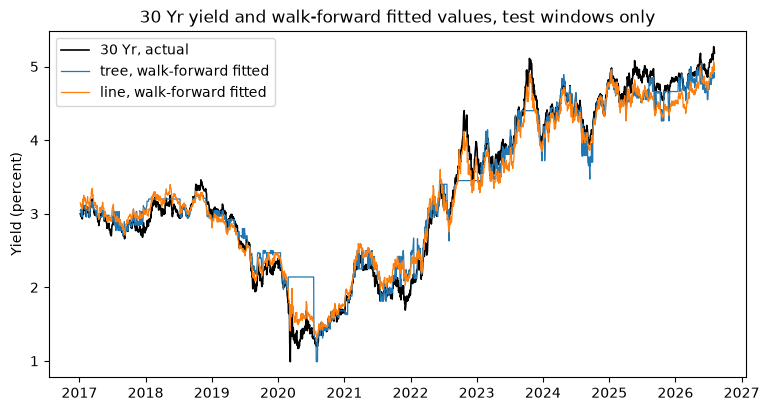

In [30]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(y.loc[wf_tree_fitted.index], color="black", linewidth=1.2, label="30 Yr, actual")
ax.plot(wf_tree_fitted, linewidth=0.9, label="tree, walk-forward fitted")
ax.plot(wf_linear_fitted, linewidth=0.9, label="line, walk-forward fitted")
ax.set_title("30 Yr yield and walk-forward fitted values, test windows only")
ax.set_ylabel("Yield (percent)")
ax.legend()
plt.show()

* The tree's fitted values run flat wherever the actual yield leaves the range of the training rows, and they jump at the start of each fold, when the training rows grow. The line follows the level further but sits off it by a slowly changing amount.
* Every point on the chart is a fitted 30 Yr yield given the same day's 2 Yr and 10 Yr, for a date inside the file.

## 11.6 A Relationship That Drifts

The line has a different problem: the plane it fits through the early dates is not the plane that fits the later ones.

Q. What coefficients does the line get in each walk-forward fold?

In [31]:
# coef_ holds one number per feature, in X's column order: 2 Yr, then 10 Yr (percent of 30 Yr per percent)
coefficients = pd.DataFrame([model.coef_ for model in wf_linear_models], columns=["2 Yr", "10 Yr"],
                            index=pd.RangeIndex(1, len(wf_linear_models) + 1, name="fold"))
coefficients["intercept"] = [model.intercept_ for model in wf_linear_models]
print(coefficients.round(4).to_string())

        2 Yr   10 Yr  intercept
fold                           
1     0.0591  0.9328     0.8176
2    -0.0918  0.9258     0.9389
3    -0.2184  0.9616     0.9674
4    -0.2836  0.9553     1.0383
5    -0.2622  0.9526     1.0230
6    -0.2215  0.9004     1.0956
7    -0.2540  0.9680     0.9815
8    -0.2844  1.0713     0.7842
9    -0.2870  1.0890     0.7462
10   -0.2605  1.0723     0.7372
11   -0.2455  1.0749     0.6975
12   -0.2607  1.0830     0.6914
13   -0.2278  1.0691     0.6849
14   -0.1975  1.0528     0.6849
15   -0.1937  1.0695     0.6491
16   -0.1936  1.0803     0.6288
17   -0.1965  1.0892     0.6161
18   -0.2182  1.1313     0.5617
19   -0.2469  1.1843     0.4963


* The weight on the 10 Yr runs from 0.9004 (fold 6) to 1.1843 (fold 19), and the weight on the 2 Yr from -0.2870 (fold 9) to 0.0591 (fold 1). Each fold's line is fitted on every date before its test window, so these differences are what the extra dates did to the fit.

Q. Measure the drift directly: the slope of the 30 Yr's daily change on the 10 Yr's daily change, over a trailing 252-row window.

2,688 windows, the first ending 2016-01-05
lowest 0.749 on 2023-07-17; highest 1.125 on 2021-03-09; last 0.807 on 2026-10-02


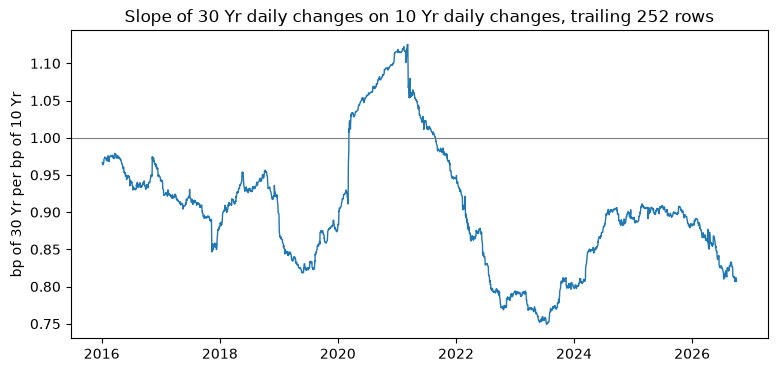

In [32]:
# daily changes in bp; the first date has no day before, so it is dropped
changes_bp = (curve.diff() * 100).iloc[1:]
# a trailing 252-row slope: covariance over variance, both over the same window, ending on each date
beta_252 = (changes_bp["30 Yr"].rolling(252).cov(changes_bp["10 Yr"]) / changes_bp["10 Yr"].rolling(252).var()).dropna()
print(f"{len(beta_252):,} windows, the first ending {beta_252.index[0].date()}")
print(f"lowest {beta_252.min():.3f} on {beta_252.idxmin().date()}; highest {beta_252.max():.3f} on {beta_252.idxmax().date()}; "
      f"last {beta_252.iloc[-1]:.3f} on {beta_252.index[-1].date()}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(beta_252, linewidth=1)
ax.axhline(1, color="grey", linewidth=0.8)
ax.set_title("Slope of 30 Yr daily changes on 10 Yr daily changes, trailing 252 rows")
ax.set_ylabel("bp of 30 Yr per bp of 10 Yr")
plt.show()

* Over the 2,688 windows the slope runs from 0.749 on 2023-07-17 to 1.125 on 2021-03-09; on the file's last date it is 0.807. Each value uses only its own trailing window, so each one describes a stretch of the file's history, and none says anything about the dates after it.
* This is a trailing window of the kind Course 3 day 7 built and tested for lookahead. Here it shows why a model fitted on one stretch of dates can miss on another: the relationship it learned moved. A random split hides that, because its training rows come from every stretch at once.

## 11.7 Ridge and Lasso Where the Features Are Collinear

On day 5, ridge and lasso did not beat plain least squares on the benchmark bonds: a few hundred rows and features the generator mostly made independent are not a setting where shrinkage helps. The curve is the opposite case. Tenors next to each other move almost together, so their columns carry nearly the same information.

The task changes to daily changes, which do not repeat the way levels do (section 11.1): **the 30 Yr's change on a date, given the same day's changes in the other ten full tenors**, all in bp. It is still a description of one date's row: how the long end's move lined up with the rest of the curve's moves that same day. The output is a fitted same-day 30 Yr change, never a forecast.

Q. Set the features and the target, and see how closely the tenors move together.

In [33]:
other_tenors = [column for column in full_tenors if column != "30 Yr"]
X_changes = changes_bp[other_tenors]   # the same day's changes in the other ten tenors, bp
y_changes = changes_bp["30 Yr"]        # the 30 Yr's change that day, bp
print(f"{len(X_changes):,} dates, {X_changes.shape[1]} features")
print(f"correlation of 20 Yr and 10 Yr daily changes: {X_changes['20 Yr'].corr(X_changes['10 Yr']):.4f}")

# day 3's VIF: how much of each column the other nine reproduce
mlkit.vif_table(X_changes).round(2).to_frame().T

2,939 dates, 10 features
correlation of 20 Yr and 10 Yr daily changes: 0.9529


,7 Yr,10 Yr,5 Yr,3 Yr,20 Yr,2 Yr,1 Yr,6 Mo,3 Mo,1 Mo
vif,60.58,52.65,45.63,23.48,16.57,13.05,4.99,3.29,1.79,1.03


* The 20 Yr and 10 Yr daily changes have a correlation of 0.9529. 6 of the ten columns have a VIF above 10, day 3's "very high" convention; the highest are 7 Yr (60.58), 10 Yr (52.65), and 5 Yr (45.63). This is real collinearity.

Q. Score least squares, ridge, and lasso on the walk-forward folds of the changes, each in a pipeline with its scaler.

In [34]:
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

change_splits = mlkit.walk_forward_splits(changes_bp.index, min_train=504, test_size=126)
for train, test in change_splits:
    mlkit.assert_past_only(changes_bp.index[train], changes_bp.index[test])

# alpha is chosen inside each fold's training rows, by folds that are also in time order
shrinkage_models = {
    "linear (OLS)": make_pipeline(StandardScaler(), LinearRegression()),
    "ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 25), cv=TimeSeriesSplit(n_splits=5))),
    "lasso": make_pipeline(StandardScaler(), LassoCV(cv=TimeSeriesSplit(n_splits=5), max_iter=10000, random_state=SEED)),
}
expanding = {name: score_folds(model, X_changes, y_changes, change_splits, bp_per_unit=1)
             for name, model in shrinkage_models.items()}
pd.DataFrame({name: pooled(fitted, y_changes, bp_per_unit=1) for name, (_, fitted, _) in expanding.items()}).T.round(
    {"r2": 4, "mae_bp": 1, "rmse_bp": 1})

,r2,mae_bp,rmse_bp
linear (OLS),0.9604,0.7,1.0
ridge,0.9604,0.7,1.0
lasso,0.9600,0.7,1.0


* Walk-forward R-squared of the fitted same-day 30 Yr change: 0.9604 for least squares, 0.9604 for ridge, 0.9600 for lasso, over 19 folds. The three are the same to three decimals. With 504 to over 2,000 training rows, even ten collinear columns leave least squares enough data to pin its coefficients down.
* The pipeline is refitted in every fold, so each fold's scaler learns its means and standard deviations from that fold's training rows only. `RidgeCV` and `LassoCV` choose alpha with `TimeSeriesSplit` inside those training rows, so the choice never sees a later date either.

Q. What coefficients does each model end with, in the last fold?

In [35]:
# day 5's named_coefficients: the last step's coefficients, named; bp of 30 Yr change per standard deviation of each tenor's change
last_fold = pd.DataFrame({name: mlkit.named_coefficients(models[-1]) for name, (_, _, models) in expanding.items()})
last_fold.round(4)

,linear (OLS),ridge,lasso
1 Mo,-0.0171,-0.0171,-0.0082
3 Mo,0.0099,0.0099,0.0050
6 Mo,-0.0128,-0.0128,0.0000
1 Yr,0.0651,0.0651,0.0263
2 Yr,-0.0298,-0.0298,-0.0195
3 Yr,-0.1684,-0.1684,-0.1923
5 Yr,-0.7900,-0.7900,-0.7741
7 Yr,-0.5680,-0.5680,-0.2785
10 Yr,1.9662,1.9662,1.6432
20 Yr,4.4070,4.4070,4.4605


* All three put their largest weights on the 20 Yr and the 10 Yr, the tenors nearest the 30 Yr. Lasso's two largest are the 20 Yr and the 10 Yr, and it sets 1 coefficient exactly to zero (6 Mo). Ridge's chosen alpha is 0.001, small enough that its coefficients barely differ from least squares.
* Several weights are negative. With collinear features a coefficient is a difference between near-copies, not the effect of one tenor alone; day 3 made the same point with duration and years to maturity.

Q. Now the variant where shrinkage has something to do: a **rolling** window of only 63 training rows (about three months), tested on the next 21 rows, stepping forward 21 rows at a time.

In [36]:
# rolling (fixed-length) windows: the last 63 rows of each expanding window
rolling_splits = [(train[-63:], test) for train, test in mlkit.walk_forward_splits(changes_bp.index, min_train=504, test_size=21)]
rolling = {name: score_folds(model, X_changes, y_changes, rolling_splits, bp_per_unit=1)
           for name, model in shrinkage_models.items()}
rolling_table = pd.DataFrame({name: pooled(fitted, y_changes, bp_per_unit=1) for name, (_, fitted, _) in rolling.items()}).T
# how much the 10 Yr and 20 Yr weights move from fold to fold: the standard deviation across folds
for name, (_, _, models) in rolling.items():
    weights = pd.DataFrame([mlkit.named_coefficients(model) for model in models])
    rolling_table.loc[name, "10 Yr weight, std across folds"] = weights["10 Yr"].std()
    rolling_table.loc[name, "20 Yr weight, std across folds"] = weights["20 Yr"].std()
print(f"{len(rolling_splits)} rolling folds of 63 training rows")
rolling_table.round({"r2": 4, "mae_bp": 1, "rmse_bp": 1, "10 Yr weight, std across folds": 4,
                     "20 Yr weight, std across folds": 4})

115 rolling folds of 63 training rows


,r2,mae_bp,rmse_bp,"10 Yr weight, std across folds","20 Yr weight, std across folds"
linear (OLS),0.9464,0.8,1.2,1.6387,1.4126
ridge,0.9475,0.8,1.2,1.1273,1.3817
lasso,0.9497,0.8,1.1,0.8857,1.5145


* With 63 rows and ten collinear columns, shrinkage earns a small place: walk-forward R-squared 0.9464 for least squares, 0.9475 for ridge, 0.9497 for lasso, over 115 folds. The 10 Yr weight moves less from fold to fold under ridge (1.1273) and lasso (0.8857) than under least squares (1.6387). The weights are per standard deviation of each tenor's change in that fold's training rows.
* So the honest summary: shrinkage helps when rows are few and the features are near-copies; with thousands of rows it changes almost nothing. Both are facts about this file.
* A rolling window is the other common walk-forward shape: it forgets old dates, where the expanding window keeps them all. Section 11.6 is one reason a desk might prefer it. Today it is shown once.

## 11.8 Lookahead in Features

A walk-forward split keeps later **rows** out of the training set. A feature can still carry the future in by itself. The common case is a statistic of the whole history: a mean, a standard deviation, a z-score, a PCA fitted on every date. Course 3 day 8 built z-scores over a **trailing** window for exactly this reason, and Course 3 day 7 gave the test: the value on date t must be the same whether the data stops at t or runs on.

Q. Compute the 2s10s slope's z-score two ways: over the whole history, and over a trailing 252-row window.

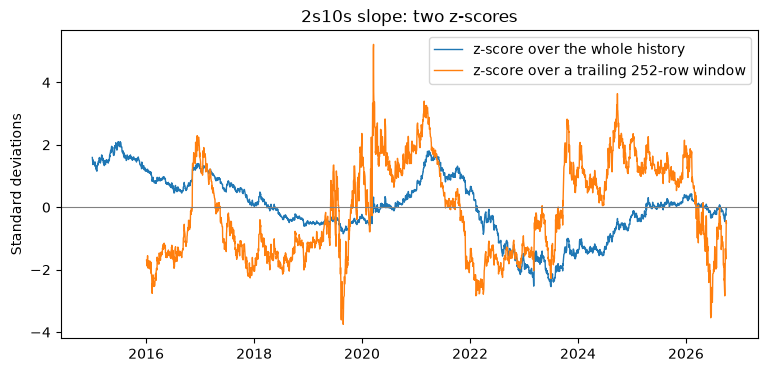

In [37]:
# the 2s10s slope in bp
slope_bp = (curve["10 Yr"] - curve["2 Yr"]) * 100

# over the whole history: every date uses the mean and standard deviation of all the dates, later ones included
z_whole_history = (slope_bp - slope_bp.mean()) / slope_bp.std()
# over a trailing window: each date uses only itself and the 251 dates before it (Course 3 day 8)
z_trailing = (slope_bp - slope_bp.rolling(252).mean()) / slope_bp.rolling(252).std()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(z_whole_history, linewidth=1, label="z-score over the whole history")
ax.plot(z_trailing, linewidth=1, label="z-score over a trailing 252-row window")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("2s10s slope: two z-scores")
ax.set_ylabel("Standard deviations")
ax.legend()
plt.show()

Q. Apply the no-lookahead test: stop the data on 2019-12-31 and compute both again.

In [38]:
cut_date = "2019-12-31"
slope_cut = slope_bp.loc[:cut_date]
z_whole_cut = (slope_cut - slope_cut.mean()) / slope_cut.std()
z_trailing_cut = (slope_cut - slope_cut.rolling(252).mean()) / slope_cut.rolling(252).std()

print(f"whole history, on {cut_date}: {z_whole_history.loc[cut_date]:.4f} with every date; {z_whole_cut.loc[cut_date]:.4f} with the data stopped there")
print(f"trailing 252 rows, on {cut_date}: {z_trailing.loc[cut_date]:.4f} with every date; {z_trailing_cut.loc[cut_date]:.4f} with the data stopped there")
print(f"trailing z-scores equal on every date up to the cut: {z_trailing.loc[:cut_date].equals(z_trailing_cut)}")
print(f"whole-history z-scores that change: {int((z_whole_history.loc[:cut_date] != z_whole_cut).sum()):,} of {len(slope_cut):,}")

whole history, on 2019-12-31: -0.2303 with every date; -0.9311 with the data stopped there
trailing 252 rows, on 2019-12-31: 2.3634 with every date; 2.3634 with the data stopped there
trailing z-scores equal on every date up to the cut: True
whole-history z-scores that change: 1,250 of 1,250


* The whole-history z-score on 2019-12-31 is -0.2303 with every date in the file and -0.9311 with the data stopped there: the number for that date was built partly from later dates. 1,250 of the 1,250 values up to the cut change. That is lookahead.
* The trailing z-score is 2.3634 either way, and every value up to the cut is identical.
* Put the whole-history z-score into a walk-forward fold as a feature, and the training rows of 2017 would carry the mean of 2026. The walk-forward split would be honest about rows and dishonest about features. The rule: a feature built from data must be built from the past only, by a trailing window or by a step inside the pipeline that is fitted on the training rows (section 11.7's scaler).

**One more number for dated residuals: Durbin-Watson.** The Durbin-Watson statistic measures how much each residual resembles the one before it: about 2 when they are unrelated, near 0 when each is almost a copy of the last.

Q. What is the Durbin-Watson statistic of the line's walk-forward residuals?

In [39]:
from statsmodels.stats.stattools import durbin_watson

# actual minus fitted, in percent, on every walk-forward test date, in date order
residuals = y.loc[wf_linear_fitted.index] - wf_linear_fitted
print(f"Durbin-Watson of the walk-forward residuals: {durbin_watson(residuals):.2f}")

Durbin-Watson of the walk-forward residuals: 0.01


* 0.01: the line's misses come in long runs, one date's miss nearly the same as the last. So 19 folds of 126 dates are much less evidence than 2,394 independent rows would be, and a fold's MAE describes a stretch of history, not 126 separate tries.

## Excel Side by Side

Excel has no walk-forward routine, and no function that refits a model fold after fold. What it does have is ranges, and a walk-forward fold is two ranges: the training rows above, the test rows below. Every formula below was typed into Excel by script on one sheet, `curve`, holding the Treasury file's 2,940 dates in order: A date, B 2 Yr, C 10 Yr, D 20 Yr, E 30 Yr, rows 2 to 2941 (Excel 16.0 build 20430, 2026-10-04).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Daily change in bp | `curve.diff() * 100` | `=(C3-C2)*100` in F3 (10 Yr), the same in G (20 Yr) and H (30 Yr), filled down | equal to Python exactly |
| Correlation of 20 Yr and 10 Yr changes | `X_changes["20 Yr"].corr(X_changes["10 Yr"])` | `=CORREL(G3:G2941,F3:F2941)` | 0.9529 |
| Rolling 252-row slope of 30 Yr on 10 Yr changes | `beta_252` (section 11.6) | `=SLOPE(OFFSET(H254,-251,0,252,1),OFFSET(F254,-251,0,252,1))` in I254, filled down | lowest 0.749 on 2023-07-17, highest 1.125 on 2021-03-09, last 0.807 |
| Fold 1: the line fitted on training rows 2 to 505, fitted values for test rows 506 to 631 | `wf_linear_fitted` for fold 1 | `=TREND($E$2:$E$505,$B$2:$C$505,B506:C506)` in J506, filled down to J631 | first fitted value 3.1471 percent |
| Fold 1's MAE in bp | `wf_linear_folds.loc[1, "mae_bp"]` | `=AVERAGE(ABS(E506:E631-J506:J631))*100` | 11.9 bp |
| 2s10s slope in bp | `slope_bp` | `=(C2-B2)*100` in K2, filled down | equal to Python exactly |
| z-score over the whole history | `z_whole_history` | `=STANDARDIZE(K2,AVERAGE($K$2:$K$2941),STDEV.S($K$2:$K$2941))` in L2, filled down | on 2019-12-31: -0.2303 |
| z-score over a trailing 252 rows | `z_trailing` | `=STANDARDIZE(K253,AVERAGE(K2:K253),STDEV.S(K2:K253))` in M253, filled down | on 2019-12-31: 2.3634 |

**The rolling slope.** `OFFSET(H254,-251,0,252,1)` starts at H254, moves up 251 rows, and takes a block 252 rows tall and 1 column wide: rows 3 to 254, the first 252 daily changes. Filled down one row, it becomes `=SLOPE(OFFSET(H255,-251,0,252,1),OFFSET(F255,-251,0,252,1))`, the window moved one date later. `SLOPE` of those two blocks is the least squares slope over that window, which is what `cov / var` computes in pandas.

**One walk-forward fold as ranges.** `TREND(known_y's, known_x's, new_x's)` fits least squares on the first two ranges and returns the fitted value for the third. The dollar signs lock the training block, rows 2 to 505 (2015-01-02 to 2017-01-05, the first 504 dates); only `B506:C506` moves when it is filled down (`=TREND($E$2:$E$505,$B$2:$C$505,B507:C507)` in J507). That is fold 1 of `walk_forward_splits`, written as a formula: the line never sees a test row. The next fold would lock rows 2 to 631 and fill down the next 126 rows; that repetition is what `walk_forward_splits` and `score_folds` do for every fold.

**The dollar signs are the lookahead.** In `=STANDARDIZE(K2,AVERAGE($K$2:$K$2941),STDEV.S($K$2:$K$2941))`, `$K$2:$K$2941` is every date of the file, so the row for 2015-01-02 already holds the mean of 2026-10-02. In `=STANDARDIZE(K253,AVERAGE(K2:K253),STDEV.S(K2:K253))` the range moves with the row, so each date uses only itself and the 251 dates above it. The same test as section 11.8, in Excel: with the 2s10s values after 2019-12-31 cleared, the whole-history z-score on 2019-12-31 changed from -0.2303 to -0.9311, and the trailing one stayed at 2.3634.

In [40]:
# Excel's numbers, from the day's Excel check, beside Python's for the same rows
excel_values = {
    "correlation, 20 Yr and 10 Yr changes": 0.9529200494080029,
    "rolling slope, lowest": 0.749120295543754,
    "rolling slope, highest": 1.1254900623870732,
    "rolling slope, last": 0.8069304473017922,
    "fold 1 MAE (bp)": 11.947066016593745,
    "z whole history, 2019-12-31": -0.23031487924785904,
    "z trailing 252, 2019-12-31": 2.3634341395348297,
}
python_values = {
    "correlation, 20 Yr and 10 Yr changes": X_changes["20 Yr"].corr(X_changes["10 Yr"]),
    "rolling slope, lowest": beta_252.min(),
    "rolling slope, highest": beta_252.max(),
    "rolling slope, last": beta_252.iloc[-1],
    "fold 1 MAE (bp)": wf_linear_folds.loc[1, "mae_bp"],
    "z whole history, 2019-12-31": z_whole_history.loc["2019-12-31"],
    "z trailing 252, 2019-12-31": z_trailing.loc["2019-12-31"],
}
side_by_side = pd.DataFrame({"Excel": excel_values, "Python": python_values})
side_by_side["within 1e-9"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-9
side_by_side.round({"Excel": 4, "Python": 4})

,Excel,Python,within 1e-9
"correlation, 20 Yr and 10 Yr changes",0.9529,0.9529,True
"rolling slope, lowest",0.7491,0.7491,True
"rolling slope, highest",1.1255,1.1255,True
"rolling slope, last",0.8069,0.8069,True
fold 1 MAE (bp),11.9471,11.9471,True
"z whole history, 2019-12-31",-0.2303,-0.2303,True
"z trailing 252, 2019-12-31",2.3634,2.3634,True


* Every number matches. Excel and Python agree on what each window holds; neither can tell you whether a window reaches into the future. That is the formula writer's job, and the test's.

## Save the Day with Git

Today's Git step asks a question about history: **which commit added each function?** `git blame` answers it line by line, as it did in Course 3. It needs a history, and this work folder is new today, so the next cells rebuild one commit per week from the start-of-day files, then commit today's work on top. Your own `my_bondmath` folder already has the real history, one commit a day.

Q. Make the work folder a repository.

In [41]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [42]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_11_9fyoz8u_ and nowhere else


* Git is working in the work folder and nowhere else.

Each day's code was added at the end of the two files, so an earlier week's file is the front part of today's: the module at the end of week 1 is everything above the first line week 2 added. The next cell cuts the files back and writes the end of week 1, then the end of week 2. It writes with `newline="\n"`, so the files keep the same line endings on every machine.

Q. Write the files as they stood at the end of week 1.

In [43]:
def through(text, first_line_of_next):
    """The file as it stood before `first_line_of_next` was added: everything above that line."""
    cut = text.index("\n" + first_line_of_next)
    return text[:cut].rstrip("\n") + "\n"


# today's files, kept in memory while the history is written
module_today = Path("mlkit.py").read_text(encoding="utf-8")
tests_today = Path("test_mlkit.py").read_text(encoding="utf-8")
# the first line week 2 added to each file, and the first line today added
week2_starts = {"mlkit.py": 'def odds_ratios(coefficients: pd.Series) -> pd.Series:', "test_mlkit.py": 'from sklearn.linear_model import LogisticRegression'}
today_starts = {"mlkit.py": 'def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,', "test_mlkit.py": 'from sklearn.model_selection import TimeSeriesSplit'}

Path("mlkit.py").write_text(through(module_today, week2_starts["mlkit.py"]), encoding="utf-8", newline="\n")
Path("test_mlkit.py").write_text(through(tests_today, week2_starts["test_mlkit.py"]), encoding="utf-8", newline="\n")
print(f"end of week 1: mlkit.py {len(Path('mlkit.py').read_text(encoding='utf-8').splitlines())} lines")

end of week 1: mlkit.py 212 lines


In [44]:
!git -C "{work}" add mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Week 1: regression on the spread cross-section"

Q. Write the files as they stood at the end of week 2, and commit them.

In [45]:
Path("mlkit.py").write_text(through(module_today, today_starts["mlkit.py"]), encoding="utf-8", newline="\n")
Path("test_mlkit.py").write_text(through(tests_today, today_starts["test_mlkit.py"]), encoding="utf-8", newline="\n")
print(f"end of week 2: mlkit.py {len(Path('mlkit.py').read_text(encoding='utf-8').splitlines())} lines")

end of week 2: mlkit.py 407 lines


In [46]:
!git -C "{work}" add mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Week 2: classification on the card file"

Q. Put today's files back, see what changed, and commit them.

In [47]:
Path("mlkit.py").write_text(module_today, encoding="utf-8", newline="\n")
Path("test_mlkit.py").write_text(tests_today, encoding="utf-8", newline="\n")
print(f"today: mlkit.py {len(module_today.splitlines())} lines")

today: mlkit.py 470 lines


In [48]:
# today's two functions and five tests, then the commit, then the history
!git -C "{work}" diff --stat
!git -C "{work}" add mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Day 11: walk_forward_splits and assert_past_only, with five tests"
!git -C "{work}" log --oneline

 mlkit.py      | 63 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_mlkit.py | 63 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 2 files changed, 126 insertions(+)


c34e49c Day 11: walk_forward_splits and assert_past_only, with five tests
b72aeb0 Week 2: classification on the card file
af58750 Week 1: regression on the spread cross-section


* Three commits, newest first. The hashes are different on every run.

Q. Which commit added `regression_metrics`, `cv_folds`, and `walk_forward_splits`? Ask `git blame` for the line that starts each one.

In [49]:
# -s hides author and date; --root shows the first commit plainly; -L "/text/,+1" is the one line holding the text
!git -C "{work}" blame -s --root -L "/def regression_metrics/,+1" -L "/def cv_folds/,+1" -L "/def walk_forward_splits/,+1" mlkit.py

af587504  49) def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
b72aeb00 339) def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
c34e49c3 410) def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,


* Each line starts with the short hash of the commit that added it, then its line number in `mlkit.py`. Match the hashes to the log: `regression_metrics` came in week 1, `cv_folds` in week 2, `walk_forward_splits` today.
* In your own folder, with a commit a day, the same command names the day. Without `-s` it also shows who made each change and when.

## Bring It Home

Add today's functions and tests to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code, with the course's `.venv` active.

**Step 1.** Go to your folder, copy in the Treasury file (today's tests read it), and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
Copy-Item "$HOME\projects\python-fixed-income\data\treasury_par_yields.csv" .
code mlkit.py
code test_mlkit.py
```

**Step 2.** Paste the code of the two `%%writefile -a mlkit.py` cells (section 11.4), without their first lines, at the end of `mlkit.py`, one after the other; do the same for the two `test_mlkit.py` cells. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_mlkit.py
```

The last line says `47 passed`.

**Step 4.** Read what changed, commit the code only (the data file is a copy, never committed), and ask `git blame` today's question in your real history.

```powershell
git diff --stat
git add mlkit.py test_mlkit.py
git commit -m "Day 11: walk_forward_splits and assert_past_only, with five tests"
git blame -L "/def walk_forward_splits/,+1" mlkit.py
```

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say why a random split flatters a model on dated rows: each test date has a near-copy in the training rows.
* Build walk-forward folds with `walk_forward_splits`, check them with `assert_disjoint` and `assert_past_only`, and compare them with `TimeSeriesSplit`.
* Score a model fold by fold and over every test row, and describe a fold's error by its dates and numbers.
* Say why a tree cannot give a fitted value outside the range of its training targets, and why that matters in time order.
* Measure a drifting relationship with a trailing window, in pandas and with `SLOPE(OFFSET(...))` in Excel.
* Use ridge and lasso in a pipeline refitted in each fold, and say when shrinkage helps: few rows, near-copy features.
* Test a feature for lookahead by stopping the data at a date, and read a Durbin-Watson statistic.
* Find the commit behind a line with `git blame`.

Tomorrow, day 12, the course leaves targets behind: learning without a target, starting with scaling and K-means on the benchmark bonds.

## Exercises

The exercises use the same Treasury file, inside its own span (2015-01-02 to 2026-10-02). Every target is a same-day yield: nothing here looks at a later date. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the curve, makes the walk-forward folds, defines the section 11.3 helper, and defines `check`, a small function that marks your answers.

In [50]:
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor

# the eleven full tenors, in percent, one row per date
treasury = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"]).set_index("date")
curve = treasury[[column for column in treasury.columns if treasury[column].notna().all()]]
X, y = curve[["2 Yr", "10 Yr"]], curve["30 Yr"]
wf_splits = mlkit.walk_forward_splits(curve.index, min_train=504, test_size=126)


def score_folds(model, X, y, splits, bp_per_unit):
    """Section 11.3's helper: per-fold table, every test row's fitted value, the fitted models."""
    rows, fitted_parts, models = [], [], []
    for number, (train, test) in enumerate(splits, start=1):
        fitted_model = clone(model).fit(X.iloc[train], y.iloc[train])
        fitted = pd.Series(fitted_model.predict(X.iloc[test]), index=X.index[test])
        metrics = mlkit.regression_metrics(y.iloc[test], fitted)
        rows.append({"fold": number, "mae_bp": metrics["mae"] * bp_per_unit, "r2": metrics["r2"]})
        fitted_parts.append(fitted)
        models.append(fitted_model)
    return pd.DataFrame(rows).set_index("fold"), pd.concat(fitted_parts).sort_index(), models


def pooled_mae_bp(fitted, y, bp_per_unit):
    """MAE in bp over every test row of every fold."""
    return mlkit.regression_metrics(y.loc[fitted.index], fitted)["mae"] * bp_per_unit


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Fit the 20 Yr yield given the same day's 5 Yr and 10 Yr yields. Score a `LinearRegression` and a `DecisionTreeRegressor(random_state=SEED)` on the walk-forward folds `wf_splits`, and store each one's MAE in bp over every test row in **ex1_linear_mae_bp** and **ex1_tree_mae_bp**.

In [51]:
ex1_linear_mae_bp = ...
ex1_tree_mae_bp = ...

In [52]:
check("Exercise 1 the line", ex1_linear_mae_bp, 10.528321155976876)
check("Exercise 1 the tree", ex1_tree_mae_bp, 13.197159565580618)

Exercise 1 the line: not attempted yet
Exercise 1 the tree: not attempted yet


### Exercise 2

Q. Make walk-forward folds of the curve with a gap of 21 rows (`min_train=504`, `test_size=126`, `gap=21`), check every fold with `mlkit.assert_past_only(..., gap=21, calendar=curve.index)`, and store the tree's MAE in bp over every test row (30 Yr given the 2 Yr and 10 Yr, `DecisionTreeRegressor(random_state=SEED)`) in **ex2_tree_mae_bp**.

In [53]:
ex2_tree_mae_bp = ...

In [54]:
check("Exercise 2 the tree with a gap of 21", ex2_tree_mae_bp, 17.74711779448622)

Exercise 2 the tree with a gap of 21: not attempted yet


### Exercise 3

Q. Add a function to your module. `fold_dates(dates, splits)` returns a table with one row per fold, numbered from 1, and the columns `train_first`, `train_last`, `test_first`, `test_last` (Timestamps); it raises `ValueError` if `splits` is empty or a fold has an empty part. Write the docstring first. Then add `test_fold_dates_hand_values`, which checks the ten hand-made business days of `test_walk_forward_hand_index` (`min_train=4`, `test_size=2`) and that an empty `splits` raises. Run pytest, reload the module, and store the last fold's last test date of `fold_dates(curve.index, wf_splits)` as text, `"YYYY-MM-DD"`, in **ex3_last_test_date**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [55]:
%%writefile -a mlkit.py


# Exercise 3: write fold_dates(dates, splits) below this line

Appending to mlkit.py


In [56]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_fold_dates_hand_values() below this line

Appending to test_mlkit.py


In [57]:
# run pytest, reload the module, then call your function
ex3_last_test_date = ...

In [58]:
check("Exercise 3 the last test date", ex3_last_test_date, '2026-08-04')

Exercise 3 the last test date: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that scores a model in time order, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Walk-forward MAE of a model on the Treasury file, in bp, for a desk table.

    Folds: five, in time order: every fold is fitted on dates before every date it is tested on.
    Rows are never shuffled. y is a yield in percent.
    Returns: the list of (train_positions, test_positions) used, and the MAE in bp over every
    test row of every fold.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a number of the right size, and contains one bug.

In [59]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def walk_forward_mae(model, X, y):
    """Walk-forward MAE of a model on the Treasury file, in bp, for a desk table.

    Folds: five, in time order: every fold is fitted on dates before every date it is tested on.
    Rows are never shuffled. y is a yield in percent.
    Returns: the list of (train_positions, test_positions) used, and the MAE in bp over every
    test row of every fold.
    """
    # five folds, with every part of the history represented in each one
    folds = list(KFold(n_splits=5, shuffle=True, random_state=SEED).split(X))
    actual_parts, fitted_parts = [], []
    for train, test in folds:
        model.fit(X.iloc[train], y.iloc[train])
        fitted_parts.append(model.predict(X.iloc[test]))
        actual_parts.append(y.iloc[test].to_numpy())
    mae_bp = mlkit.regression_metrics(np.concatenate(actual_parts), np.concatenate(fitted_parts))["mae"] * 100
    return folds, mae_bp

Q. Before you run the next cell: will the tree's MAE from `walk_forward_mae` be higher than, equal to, or lower than the 23.0 bp of `TimeSeriesSplit(5)` in section 11.4? The docstring asks for five folds in time order.

In [60]:
ai_folds, ai_mae_bp = walk_forward_mae(DecisionTreeRegressor(random_state=SEED), X, y)
print(f"MAE from walk_forward_mae: {ai_mae_bp:.1f} bp over {len(ai_folds)} folds")

MAE from walk_forward_mae: 4.5 bp over 5 folds


Q. Test the function against its docstring before you trust it.

In [61]:
# the test, written from the docstring before the code is trusted
ai_folds, ai_mae_bp = walk_forward_mae(DecisionTreeRegressor(random_state=SEED), X, y)

# every fold: its latest training date before its earliest test date (assert_past_only's check, written out here
# so the message stops in this cell)
for train, test in ai_folds:
    last_train, first_test = X.index[train].max(), X.index[test].min()
    assert last_train < first_test, f"a training date ({last_train.date()}) is not before the first test date ({first_test.date()})"
print("walk_forward_mae fits every fold on the past only")

AssertionError: a training date (2026-10-01) is not before the first test date (2015-01-21)

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's MAE in bp for `DecisionTreeRegressor(random_state=SEED)` in **ex4_tree_mae_bp**.

In [62]:
# fix the function above and run the test again, then store the answer
ex4_tree_mae_bp = ...

In [63]:
check("Exercise 4 the fixed function's MAE", ex4_tree_mae_bp, 23.02510204081633)

Exercise 4 the fixed function's MAE: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```